In [155]:
#imports 

# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import time
from datetime import date

import requests
from bs4 import BeautifulSoup
from datetime import datetime

# Question 1: [Macro] Average growth of GDP in 2023

## What is the average growth (in %) of GDP in 2023?

- Download the timeseries Real Gross Domestic Product (GDPC1) from [FRED](https://fred.stlouisfed.org/series/GDPC1). 
- Calculate year-over-year (YoY) growth rate (that is, divide current value to one 4 quarters ago). 
- Find the average YoY growth in 2023 (average from 4 YoY numbers). Round to 1 digit after the decimal point: e.g. if you get 5.66% growth => you should answer 5.7

In [20]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year-70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')


# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPC1", "fred", start=start)

Year = 2024; month= 4; day=21
Period for indexes: 1954-04-21 to 2024-04-21 


In [21]:
gdppot['gdppot_us_yoy'] = gdppot.GDPC1/gdppot.GDPC1.shift(4)-1
gdppot.tail(10)

,GDPC1,gdppot_us_yoy
DATE,,
2021-07-01,21483.083,0.047353
2021-10-01,21847.602,0.054211
2022-01-01,21738.871,0.035651
2022-04-01,21708.160,0.018706
2022-07-01,21851.134,0.017132
2022-10-01,21989.981,0.006517
2023-01-01,22112.329,0.017179
2023-04-01,22225.350,0.023825
2023-07-01,22490.692,0.029269


In [22]:
# Find the average YoY growth in 2023 (average from 4 YoY numbers). Round to 1 digit after the decimal point: e.g. if you get 5.66% growth => you should answer 5.7
gdppot_2023 = gdppot.loc['2023']

round(gdppot_2023['gdppot_us_yoy'].mean()*100,1)

2.5

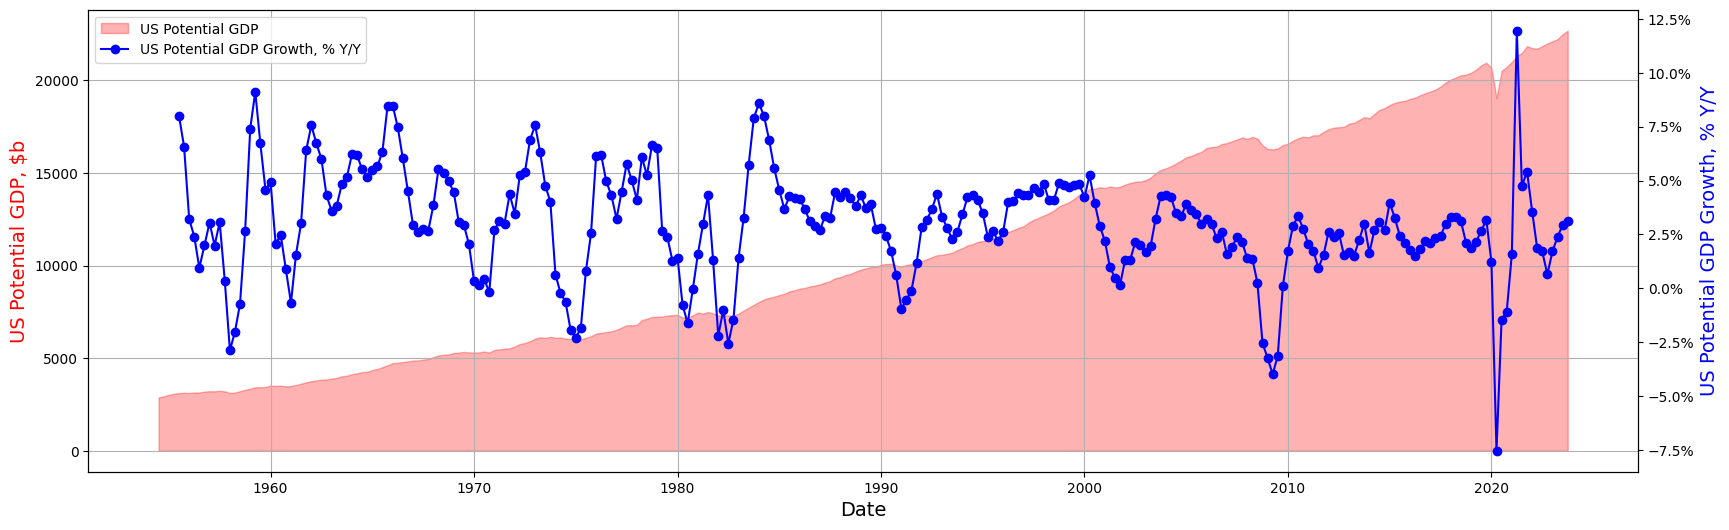

In [24]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
ax.fill_between(gdppot.index, gdppot.GDPC1, color="red", alpha=0.3, label="US Potential GDP")

# Creating a secondary y-axis for GDP growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# Question 2. [Macro] Inverse "Treasury Yield"

## Find the min value of (dgs10-dgs2) after since year 2000 (2000-01-01) and write it down as an answer, round to 1 digit after the decimal point.

Download DGS2 and DGS10 interest rates series (https://fred.stlouisfed.org/series/DGS2, https://fred.stlouisfed.org/series/DGS10). Join them together to one dataframe on date (you might need to read about pandas.DataFrame.join()), calculate the difference dgs10-dgs2 daily.

(Additional: think about what does the "inverted yield curve" mean for the market and investors? do you see the same thing in your country/market of interest? Do you think it can be a good predictive feature for the models?)

In [30]:
dgs2pot = pdr.DataReader("DGS2", "fred", start=start)
dgs10pot = pdr.DataReader("DGS10", "fred", start=start)

# Merge the two DataFrames
dgs = dgs2pot.join(dgs10pot, how='inner', lsuffix='_2', rsuffix='_10')
dgs['dgs_diff'] = dgs.DGS10 - dgs.DGS2

# Find the date when the difference between 10-year and 2-year Treasury yields was the smallest in 2000-2023. 
# Round to 1 digit after the decimal point: e.g. if you get 1.2345% => you should answer 1.2
round(dgs.loc['2000-01-01':].dgs_diff.min(),1)

-1.1

- An inverted yield curve occurs when the yields on short-term bonds are higher than the yields on long-term bonds. Typically, long-term bonds offer higher yields because investors demand higher returns for tying up their money for a longer period. However, when short-term yields surpass long-term yields, it signals investor expectations of economic downturn or recession in the future.

- For the market and investors, an inverted yield curve often serves as a warning sign. It suggests that investors anticipate weaker economic growth, which can lead to reduced borrowing, decreased consumer spending, and ultimately, a contraction in economic activity. Consequently, stock markets may react negatively to an inverted yield curve due to the uncertainty and potential for decreased corporate profits.

- In my country/market of interest, inverted yield curves can have similar implications, though the specific economic factors driving them may vary. Economic indicators, such as unemployment rates, GDP growth, and consumer sentiment, may influence investor expectations and shape yield curve dynamics.

- As for predictive modeling, an inverted yield curve is considered a valuable feature for forecasting economic trends. Historical data shows that inversions often precede recessions, making them a useful tool for economic analysts and modelers. Including the inverted yield curve as a feature in predictive models can enhance their accuracy in anticipating economic downturns, enabling investors and policymakers to make informed decisions. However, it's essential to consider other factors and indicators alongside the yield curve to build robust predictive models

# Question 3. [Index] Which Index is better recently?

## Compare S&P 500 and IPC Mexico indexes by the 5 year growth and write down the largest value as an answer (%)

Download on Yahoo Finance two daily index prices for S&P 500 (^GSPC, https://finance.yahoo.com/quote/%5EGSPC/) and IPC Mexico (^MXX, https://finance.yahoo.com/quote/%5EMXX/). Compare 5Y growth for both (between 2019-04-09 and 2024-04-09). Select the higher growing index and write down the growth in % (closest integer %). E.g. if ratio end/start was 2.0925 (or growth of 109.25%), you need to write down 109 as your answer.

(Additional: think of other indexes and try to download stats and compare the growth? Do create 10Y and 20Y growth stats. What is an average yearly growth rate (CAGR) for each of the indexes you select?)

In [64]:
# Download data
gspc_daily = yf.download('^GSPC', start='2019-04-09', end='2024-04-09', interval='1d')
mxx_daily = yf.download('^MXX', start='2019-04-09', end='2024-04-09', interval='1d')

# Calculate cumulative growth rates
gspc_start_price = gspc_daily['Adj Close'].iloc[0]
gspc_end_price = gspc_daily['Adj Close'].iloc[-1]
gspc_growth_ratio = (gspc_end_price / gspc_start_price) - 1

mxx_start_price = mxx_daily['Adj Close'].iloc[0]
mxx_end_price = mxx_daily['Adj Close'].iloc[-1]
mxx_growth_ratio = (mxx_end_price / mxx_start_price) - 1

# Select the higher growing index and write down the growth in % (closest integer %)
if gspc_growth_ratio > mxx_growth_ratio:
    higher_growth = gspc_growth_ratio
    print("S&P 500 had higher growth.")
else:
    higher_growth = mxx_growth_ratio
    print("IPC Mexico had higher growth.")

# Convert growth to percentage (closest integer %)
growth_percentage = round(higher_growth * 100)
print("Growth rate: {}%".format(growth_percentage))

[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed

S&P 500 had higher growth.
Growth rate: 81%


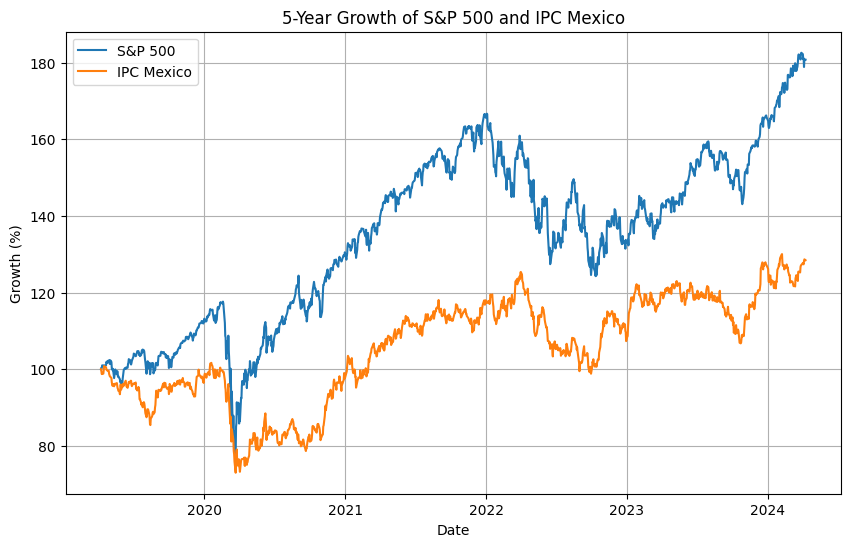

In [65]:
# Calculate cumulative growth rates
gspc_start_price = gspc_daily['Adj Close'].iloc[0]
gspc_growth = (gspc_daily['Adj Close'] / gspc_start_price) * 100

mxx_start_price = mxx_daily['Adj Close'].iloc[0]
mxx_growth = (mxx_daily['Adj Close'] / mxx_start_price) * 100

# Plot the growth of both indices
plt.figure(figsize=(10, 6))
plt.plot(gspc_daily.index, gspc_growth, label='S&P 500')
plt.plot(mxx_daily.index, mxx_growth, label='IPC Mexico')
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.title('5-Year Growth of S&P 500 and IPC Mexico')
plt.legend()
plt.grid(True)
plt.show()

# Question 4. [Stocks OHLCV] 52-weeks range ratio (2023) for the selected stocks

## Find the largest range ratio [=(max-min)/max] of Adj.Close prices in 2023

Download the 2023 daily OHLCV data on Yahoo Finance for top6 stocks on earnings (https://companiesmarketcap.com/most-profitable-companies/): 2222.SR,BRK-B, AAPL, MSFT, GOOG, JPM.

Here is the example data you should see in Pandas for "2222.SR": https://finance.yahoo.com/quote/2222.SR/history

Calculate maximum-minimim "Adj.Close" price for each stock and divide it by the maximum "Adj.Close" value. Round the result to two decimal places (e.g. 0.1575 will be 0.16)

(Additional: why this may be important for your research?)

In [70]:
# List of stock symbols
stocks = ['2222.SR', 'BRK-B', 'AAPL', 'MSFT', 'GOOG', 'JPM']

# Initialize variables to store the maximum range ratio and the corresponding stock
max_range_ratio = 0
max_range_stock = ""

# Iterate through each stock to find the maximum range ratio
for stock in stocks:
    # Download data
    data = yf.download(stock, start='2023-01-01', end='2023-12-31')
    
    # Calculate the range ratio
    max_adj_close = data['Adj Close'].max()
    min_adj_close = data['Adj Close'].min()
    range_ratio = (max_adj_close - min_adj_close) / max_adj_close
    
    # Update maximum range ratio and corresponding stock if applicable
    if range_ratio > max_range_ratio:
        max_range_ratio = range_ratio
        max_range_stock = stock

# Print the result
print(f"The largest range ratio in 2023 is {max_range_ratio:.2f}, found in stock {max_range_stock}.")

[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

The largest range ratio in 2023 is 0.42, found in stock MSFT.


# Question 5. [Stocks] Dividend Yield

## Find the largest dividend yield for the same set of stocks

Use the same list of companies (2222.SR,BRK-B, AAPL, MSFT, GOOG, JPM) and download all dividends paid in 2023. You can use get_actions() method or .dividends field in yfinance library (https://github.com/ranaroussi/yfinance?tab=readme-ov-file#quick-start)

Sum up all dividends paid in 2023 per company and divide each value by the closing price (Adj.Close) at the last trading day of the year.

Find the maximm value in % and round to 1 digit after the decimal point. (E.g., if you obtained $1.25 dividends paid and the end year stock price is $100, the dividend yield is 1.25% -- and your answer should be equal to 1.3)

In [137]:
companies = ['2222.SR', 'BRK-B', 'AAPL', 'MSFT', 'GOOG', 'JPM']

for company in companies:
    # Download adjusted close prices for the specified company for all available data
    adj_close_all = yf.download(tickers=company, period="max", interval="1d")['Adj Close']
    
    # Filter the adjusted close prices for the year 2023
    adj_close_2023 = adj_close_all.loc['2023-01-01':'2023-12-31']
    
    # Get the last adjusted close price for the year
    last_close_price = adj_close_2023.iloc[-1]
    
    # Download dividends paid in 2023 for the specified company
    dividends_2023 = yf.Ticker(company).dividends
    dividends_2023 = dividends_2023.loc['2023-01-01':'2023-12-31']
    
    # Calculate the sum of dividends paid in 2023 and the dividend yield
    total_dividends_2023 = dividends_2023.sum()
    dividend_yield = (total_dividends_2023 / last_close_price) * 100
    
    print(f"Company: {company}")
    print(f"Total dividends paid in 2023: {total_dividends_2023}")
    print(f"Dividend yield in 2023: {round(dividend_yield, 1)}%")


[*********************100%%**********************]  1 of 1 completed


Company: 2222.SR
Total dividends paid in 2023: 0.9107640000000001
Dividend yield in 2023: 2.8%


[*********************100%%**********************]  1 of 1 completed


Company: BRK-B
Total dividends paid in 2023: 0.0
Dividend yield in 2023: 0.0%


[*********************100%%**********************]  1 of 1 completed


...

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

Company: MSFT
Total dividends paid in 2023: 2.79
Dividend yield in 2023: 0.7%


Company: GOOG
Total dividends paid in 2023: 0.0
Dividend yield in 2023: 0.0%


[*********************100%%**********************]  1 of 1 completed

Company: JPM
Total dividends paid in 2023: 4.05
Dividend yield in 2023: 2.4%


# Question 6. [Exploratory] Investigate new metrics

Free text answer

Volatility (Standard Deviation of Returns): Volatility measures the degree of variation in a stock's price over time. It provides insights into the risk associated with holding a particular stock. High volatility stocks may offer higher potential returns but also come with increased risk, while low volatility stocks may provide more stability but lower potential returns

In [152]:
# List of companies
companies = ['2222.SR', 'BRK-B', 'AAPL', 'MSFT', 'GOOG', 'JPM']

# Dictionary to store average volatility for each company
average_volatility = {}

# Loop through each company
for company in companies:
    # Download historical data for the company from Yahoo Finance
    stock_data = yf.download(company, start="2023-01-01", end="2024-01-01")

    # Calculate daily returns
    stock_data['daily_return'] = stock_data['Adj Close'].pct_change()

    # Calculate the standard deviation of daily returns
    volatility = np.std(stock_data['daily_return'])

    # Store volatility in the dictionary
    average_volatility[company] = volatility

# Plot average volatility for each stock
fig = go.Figure(data=[go.Bar(x=list(average_volatility.keys()), y=list(average_volatility.values()))])
fig.update_layout(title='Average Volatility for Each Stock in 2023',
                  xaxis_title='Company',
                  yaxis_title='Average Volatility')
fig.show()

[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


# Question 7. [Exploratory] Time-driven strategy description around earnings releases

## Free text answer

Explore earning dates for the whole month of April - e.g. using YahooFinance earnings calendar (https://finance.yahoo.com/calendar/earnings?from=2024-04-21&to=2024-04-27&day=2024-04-23). Compare with the previous closed earnings (e.g., recent dates with full data https://finance.yahoo.com/calendar/earnings?from=2024-04-07&to=2024-04-13&day=2024-04-08).

Describe an analytical strategy/idea (you're not required to implement it) to select a subset companies of interest based on the future events data.

In [160]:


# Define the URL for the earnings calendar
url = "https://finance.yahoo.com/calendar/earnings"

# Define the start and end dates for the month of April
start_date = datetime(2024, 4, 1).strftime("%Y-%m-%d")
end_date = datetime(2024, 4, 30).strftime("%Y-%m-%d")

# Construct the query parameters
params = {
    "from": start_date,
    "to": end_date
}

# Send a GET request to fetch the earnings calendar data
response = requests.get(url, params=params)

# Parse the HTML content of the response
soup = BeautifulSoup(response.content, "html.parser")

# Find the table containing earnings calendar data
earnings_table = soup.find("table", class_="W(100%)")

# Extract information from the table
earnings_data = []
for row in earnings_table.find_all("tr")[1:]:
    cells = row.find_all("td")
    company_name = cells[0].text.strip()
    earnings_date = cells[1].text.strip()
    earnings_data.append({"Company": company_name, "Earnings Date": earnings_date})

# Display the earnings calendar data
for earnings in earnings_data:
    print(earnings)

{'Company': 'BWTL', 'Earnings Date': 'Bowlin Travel Centers Inc'}
{'Company': 'MDSQF', 'Earnings Date': 'Minsud Resources Corp'}
{'Company': 'KUYAF', 'Earnings Date': 'Kuya Silver Corp'}
{'Company': 'EOSS', 'Earnings Date': 'EOS Inc'}


In [156]:
# Define the URL for the previous closed earnings calendar
url = "https://finance.yahoo.com/calendar/earnings"

# Define the start and end dates for the previous week
start_date = datetime(2024, 4, 1).strftime("%Y-%m-%d")
end_date = datetime(2024, 4, 7).strftime("%Y-%m-%d")

# Construct the query parameters
params = {
    "from": start_date,
    "to": end_date
}

# Send a GET request to fetch the previous closed earnings calendar data
response = requests.get(url, params=params)

# Parse the HTML content of the response
soup = BeautifulSoup(response.content, "html.parser")

# Find the table containing earnings calendar data
earnings_table = soup.find("table", class_="W(100%)")

# Extract information from the table
previous_earnings_data = []
for row in earnings_table.find_all("tr")[1:]:
    cells = row.find_all("td")
    company_name = cells[0].text.strip()
    earnings_date = cells[1].text.strip()
    previous_earnings_data.append({"Company": company_name, "Earnings Date": earnings_date})

# Display the previous closed earnings calendar data
print("Previous Closed Earnings:")
for earnings in previous_earnings_data:
    print(earnings)

# Compare with the earnings calendar data for the month of April
print("\nComparison with April Earnings:")
for earnings in earnings_data:
    if earnings in previous_earnings_data:
        print(f"{earnings['Company']} has earnings both in the previous closed period and in April.")
    else:
        print(f"{earnings['Company']} has earnings in April but not in the previous closed period.")

Previous Closed Earnings:
{'Company': 'BWTL', 'Earnings Date': 'Bowlin Travel Centers Inc'}
{'Company': 'MDSQF', 'Earnings Date': 'Minsud Resources Corp'}
{'Company': 'KUYAF', 'Earnings Date': 'Kuya Silver Corp'}
{'Company': 'EOSS', 'Earnings Date': 'EOS Inc'}

Comparison with April Earnings:
BWTL has earnings both in the previous closed period and in April.
MDSQF has earnings both in the previous closed period and in April.
KUYAF has earnings both in the previous closed period and in April.
EOSS has earnings both in the previous closed period and in April.


- Identify Market-Moving Events: Determine which companies' earnings announcements are likely to have a significant impact on the market. Companies with large market capitalizations, high trading volumes, or strong industry influence are often prioritized.
- Analyze Historical Earnings Performance: Evaluate historical earnings performance for each company, considering factors such as earnings surprises, revenue growth rates, and stock price reactions to past earnings announcements. Identify patterns of consistent positive or negative earnings surprises.
- Consider Market Sentiment: Incorporate sentiment analysis techniques to gauge market sentiment leading up to earnings announcements. Analyze news articles, analyst reports, social media discussions, and investor sentiment indicators to assess market expectations and sentiment regarding upcoming earnings.
- Evaluate Fundamental Metrics: Assess fundamental metrics such as revenue growth, earnings stability, profitability ratios, and industry trends to identify companies with strong underlying financial performance and growth prospects.
- Use Predictive Analytics: Employ predictive analytics techniques, including machine learning models, to forecast potential earnings surprises or stock price movements based on historical data, market sentiment, and fundamental metrics. Develop predictive models that incorporate various features, such as historical earnings data, market sentiment indicators, and company-specific factors.
- Risk Management: Consider risk management principles when selecting companies for investment. Diversify the portfolio by selecting companies from different sectors or industries to mitigate sector-specific risks. Set risk tolerance levels and establish stop-loss mechanisms to manage downside risk in case of adverse earnings outcomes.
- Monitor Post-Earnings Performance: Continuously monitor companies' post-earnings performance, including stock price movements, trading volumes, and analyst reactions, to validate investment decisions and adjust strategies as needed based on actual earnings outcomes.